# 05 · Noise, hardware realism, and larger runtimes

Everything so far assumed a perfect quantum computer. Exact statevectors, no
gate errors, and — except where stated — unlimited measurement shots.

Real devices have none of those. This notebook asks what the pipeline's accuracy
would actually be on hardware, by degrading the simulation in three ways that
correspond to three distinct physical limitations:

| limitation | what it models |
|---|---|
| **shot noise** | you estimate probabilities from finite measurements |
| **gate error** | every operation is slightly wrong |
| **readout error** | measurement itself misreports the qubit |

Then it covers scaling up: GPU simulation, and where Colab's free tier runs out.

**Scope note.** This is *simulated* noise, not hardware. Nothing here was run on
a real device — that would need queue access this project did not have. What it
gives you is the shape of the degradation and roughly where the error budget
runs out, which is the useful thing for deciding whether hardware is worth
pursuing.

Runtime: about ten minutes on CPU.

## Setup

In [1]:
# Environment setup — works on Colab and on a local checkout.
#
# Safe to run in any order and any number of times. If another notebook in this
# session already cloned the repo, this reuses it rather than trying to clone
# again (which fails with "destination path already exists", exit 128).

import os, sys, subprocess, pathlib, importlib

REPO_URL = "https://github.com/Pushkar0997/qi26_25.git"
REPO_DIR = "qi26_25"
IN_COLAB = "google.colab" in sys.modules

# A file that exists only in this repo, used to recognise a valid checkout.
MARKER = pathlib.Path("integration") / "features.py"


def _is_root(p):
    return (p / MARKER).exists()


def _find_root():
    """Locate the repo, checking three places in order.

    Searching UPWARD alone is not enough. On Colab every notebook gets a fresh
    kernel starting at /content, so a second notebook would look at /content and
    its parents, miss the /content/qi26_25 that the first notebook cloned, and
    try to clone again into a directory that already exists.
    """
    here = pathlib.Path.cwd().resolve()

    # 1. Here or above — a local checkout, or a notebook opened from notebooks/.
    for cand in [here, *here.parents]:
        if _is_root(cand):
            return cand

    # 2. One level down — a clone made earlier in this session.
    for cand in [here / REPO_DIR, pathlib.Path("/content") / REPO_DIR]:
        if _is_root(cand):
            return cand.resolve()

    return None


root = _find_root()
if root is None:
    target = pathlib.Path.cwd() / REPO_DIR
    if target.exists():
        raise SystemExit(
            f"{target} exists but does not contain {MARKER}.\n"
            f"It may be a partial clone. Remove it and re-run this cell:\n"
            f"    !rm -rf {target}")
    print("cloning repository ...")
    subprocess.run(["git", "clone", "--quiet", REPO_URL, str(target)], check=True)
    root = _find_root()
    if root is None:
        raise SystemExit("clone succeeded but the repo layout was not found")
else:
    print("using existing checkout")

os.chdir(root)

# Put the package directories on the path. These modules import each other by
# bare name, so the directories themselves go on sys.path, not the repo root.
for sub in ["integration", "track_b_search/oracle", "data", "benchmarking",
            "track_a_vision/quanvolutional", "track_a_vision/encoding"]:
    d = str(root / sub)
    if d not in sys.path:
        sys.path.insert(0, d)

# Install only what is missing — Colab already ships numpy/scipy/sklearn/PIL.
need = []
for mod, pkg in [("qiskit", "qiskit>=2.0,<3.0"), ("qiskit_aer", "qiskit-aer"),
                 ("sklearn", "scikit-learn"), ("scipy", "scipy"),
                 ("PIL", "pillow"), ("matplotlib", "matplotlib")]:
    try:
        importlib.import_module(mod)
    except ImportError:
        need.append(pkg)
if need:
    print("installing:", " ".join(need))
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *need], check=True)

import qiskit, numpy as np
print("repo root :", root)
print("colab     :", IN_COLAB)
print("qiskit    :", qiskit.__version__, "| numpy:", np.__version__)

using existing checkout


repo root : D:\Coding_Work\qi26_25\qi26_25
colab     : False
qiskit    : 2.5.1 | numpy: 2.5.2


In [2]:
# Setup: data, model, imports, and the shared scoring helper.
#
# The dataset check looks for a real data file rather than manifest.json: the
# manifest is committed to the repo but the images are gitignored, so on a fresh
# clone the manifest exists while the data does not.
import subprocess, sys, json
from pathlib import Path
import numpy as np, matplotlib.pyplot as plt

TIERS = ["clean_digital", "clean_scan", "noisy_scan",
         "clear_handwriting", "degraded_handwriting"]

if not all((Path("data/processed") / t / "chars.npz").exists() for t in TIERS):
    print("generating dataset (about 30 s) ...")
    subprocess.run([sys.executable, "data/generate_dataset.py",
                    "--docs-per-tier", "12", "--seed", "26"], check=True)
if not Path("integration/ocr_backend.npz").exists():
    print("training OCR backend ...")
    subprocess.run([sys.executable, "integration/pipeline.py", "--train"], check=True)

from features import (quanv_features, normalize_crops, random_entangling_circuit,
                      quanv_patch_probs)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X = np.concatenate([np.load(f"data/processed/{t}/chars.npz")["crops"] for t in TIERS])
y = np.concatenate([np.load(f"data/processed/{t}/chars.npz")["labels"] for t in TIERS])
# Ground-truth crops rather than segmented ones: this notebook studies the quantum
# stage in isolation, and segmentation error would only add unrelated variance.
Xn = normalize_crops(X)
print("crops:", X.shape, "| classes:", len(np.unique(y)))


def score(F, seed=26):
    """Fit the standard head on 75% and report held-out accuracy.

    Used by every experiment below so that noise levels are compared on
    identical splits and an identical classifier.
    """
    a, b, c, d = train_test_split(F, y, test_size=.25, random_state=seed, stratify=y)
    return LogisticRegression(max_iter=3000, C=5.).fit(a, c).score(b, d)


# Every experiment below is measured against this number, on the same split and
# classifier, so any change can only come from the noise being modelled.
baseline = score(quanv_features(Xn, correlations=True))
print(f"noiseless baseline accuracy: {baseline:.4f}")

crops: (6023, 8, 8) | classes: 36


noiseless baseline accuracy: 0.9223


## 1 · Shot noise

The feature extractor needs probabilities, but a quantum computer only gives you
samples. With $S$ shots, each estimated probability carries error of order
$1/\sqrt{S}$.

The fast path samples from the exact distribution rather than running circuits,
which is statistically identical and enormously faster.

In [3]:
shot_levels = [16, 32, 64, 128, 256, 512, 1024, 4096, None]
shot_acc = []
# The sweep runs down to 16 shots to show where the estimate breaks, not because
# anyone would operate there. None is the exact-probability reference at the end.
for s in shot_levels:
    acc = score(quanv_features(Xn, correlations=True, shots=s))
    shot_acc.append(acc)
    print(f"  shots {str(s if s else 'exact'):>6s} -> {acc:.4f}")

  shots     16 -> 0.8486


  shots     32 -> 0.8798


  shots     64 -> 0.8918


  shots    128 -> 0.9130


  shots    256 -> 0.9197


  shots    512 -> 0.9230


  shots   1024 -> 0.9197


  shots   4096 -> 0.9203


  shots  exact -> 0.9223


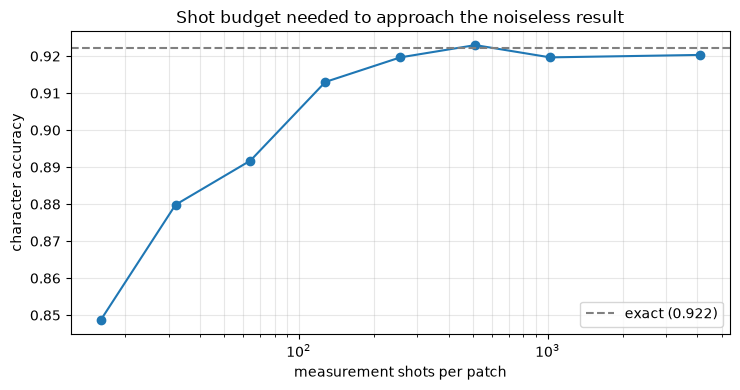

within 1 point of noiseless at 128 shots/patch
  -> 2,048 circuit executions per CHARACTER (16 patches)
  -> 12,335,104 for this dataset


In [4]:
xs = [s for s in shot_levels if s]
plt.figure(figsize=(7.5, 4))
plt.semilogx(xs, shot_acc[:-1], "o-")
plt.axhline(baseline, ls="--", c="grey", label=f"exact ({baseline:.3f})")
plt.xlabel("measurement shots per patch"); plt.ylabel("character accuracy")
plt.title("Shot budget needed to approach the noiseless result")
plt.legend(); plt.grid(alpha=.3, which="both"); plt.tight_layout(); plt.show()

# The last of the three printed lines is the one that matters: a shot budget
# quoted per patch looks modest until it is multiplied by 16 patches per
# character and then by the dataset. That total is the layer's real cost.
for s, a in zip(xs, shot_acc[:-1]):
    if a >= baseline - 0.01:
        print(f"within 1 point of noiseless at {s} shots/patch")
        print(f"  -> {s*16:,} circuit executions per CHARACTER (16 patches)")
        print(f"  -> {s*16*len(X):,} for this dataset")
        break

That last number is the honest resource cost, and it is not small. Every
published quanvolutional result carries a shot budget like this; it is usually
not stated.

## 2 · Gate noise

Now the harder question. Real gates are imperfect: a CX has error around
$10^{-3}$–$10^{-2}$ on current superconducting hardware, single-qubit gates
roughly ten times better.

Model this with a **depolarising channel** — with probability $p$ the qubit state
is replaced by the maximally mixed state:

$$\mathcal{E}(\rho) = (1-p)\,\rho + p\,\frac{I}{2^n}$$

Because the filter circuit is small (4 qubits, depth 10), a density-matrix
simulation is exact and cheap. The function below builds the noisy channel once
and applies it to patches directly, which keeps this tractable.

In [5]:
from qiskit.quantum_info import SuperOp, Operator
from qiskit_aer.noise import depolarizing_error

def noisy_superoperator(p1, p2, n_qubits=4, seed=42, depth=2):
    """Build the noisy filter as a single 256x256 superoperator.

    The same trick that made the noiseless path fast applies here. The filter is
    a FIXED circuit, so the noisy channel it implements is fixed too: walk the
    circuit once, composing each gate followed by a depolarising channel on the
    qubits it touched. The result is one linear map on vectorised density
    matrices, reusable for every patch.

    The alternative - a density-matrix simulation per patch - needs ~134,000
    simulations to sweep this dataset across seven noise levels, which does not
    finish in reasonable time. This builds in ~0.05 s and then costs one matmul.

    p1 = single-qubit gate error, p2 = two-qubit (CX) gate error.
    """
    # Walk the circuit once, composing each gate followed by a depolarising
    # channel on the qubits it touched. The order matters: the channel must
    # follow its gate, because it models that gate's imperfection.
    filt = random_entangling_circuit(n_qubits, seed, depth)
    S = SuperOp(Operator(np.eye(2 ** n_qubits)))
    for inst in filt.data:
        q = [filt.find_bit(b).index for b in inst.qubits]
        S = S.compose(SuperOp(Operator(inst.operation)), qargs=q)
        p = p1 if len(q) == 1 else p2
        if p > 0:
            S = S.compose(SuperOp(depolarizing_error(p, len(q))), qargs=q)
    return np.asarray(S.data)


def noisy_patch_features(patches, S, n_qubits=4):
    """Apply a noisy superoperator to a batch of 2x2 patches -> 10 features."""
    patches = np.asarray(patches, float)
    th = np.pi * patches / 255.0
    c, s_ = np.cos(th / 2), np.sin(th / 2)

    psi = np.ones((len(patches), 1))
    for q in range(n_qubits - 1, -1, -1):          # little-endian, qubit 0 = LSB
        psi = (psi[:, :, None] * np.stack([c[:, q], s_[:, q]], 1)[:, None, :]
               ).reshape(len(patches), -1)

    dim = 2 ** n_qubits
    rho = psi[:, :, None] * psi[:, None, :]
    # Qiskit's SuperOp acts on COLUMN-major vectorised density matrices, hence the
    # transpose before flattening and the matching one after. Skipping either
    # still yields something shaped like a distribution, but a wrong one.
    vec = rho.transpose(0, 2, 1).reshape(len(patches), -1)   # column-major vec
    out = (vec @ S.T).reshape(len(patches), dim, dim).transpose(0, 2, 1)
    probs = np.real(np.einsum("nii->ni", out))
    probs = np.clip(probs, 0, None)
    probs /= probs.sum(axis=1, keepdims=True)

    idx = np.arange(dim)
    bits = np.stack([(idx >> q) & 1 for q in range(n_qubits)])
    feats = [probs[:, bits[q] == 1].sum(1) for q in range(n_qubits)]
    z = 1.0 - 2.0 * bits
    for i in range(n_qubits):
        for j in range(i + 1, n_qubits):
            feats.append((probs * (z[i] * z[j])).sum(1))
    return np.stack(feats, axis=1)


# Correctness check: at p=0 this must reproduce the noiseless fast path.
S0 = noisy_superoperator(0.0, 0.0)
probe = Xn[:200].reshape(200, -1)[:, :4]
delta = np.abs(noisy_patch_features(probe, S0)
               - quanv_patch_probs(probe, correlations=True)).max()
print(f"superoperator shape      : {S0.shape}")
print(f"max |noisy(p=0) - exact| : {delta:.2e}")
print("-> the noise machinery is correct at p=0")

superoperator shape      : (256, 256)
max |noisy(p=0) - exact| : 5.55e-16
-> the noise machinery is correct at p=0


Now sweep gate error rates over the whole dataset. Each level is one
superoperator build plus a batched matmul, so the sweep takes seconds.

In [6]:
def noisy_features(images, S, n_qubits=4):
    """Full 8x8 crops -> 160 features, under a given noisy channel."""
    images = np.asarray(images, float)
    n, cs, ps, st = len(images), 8, 2, 2
    outw = (cs - ps) // st + 1
    patches = np.empty((n * outw * outw, 4))
    k = 0
    for oy in range(outw):
        for ox in range(outw):
            patches[k*n:(k+1)*n] = images[:, oy*st:oy*st+ps,
                                          ox*st:ox*st+ps].reshape(n, -1)
            k += 1
    f = noisy_patch_features(patches, S, n_qubits)
    return f.reshape(outw*outw, n, 10).transpose(1, 0, 2).reshape(n, -1)

import time
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

F_clean_full = quanv_features(Xn, correlations=True)
idx_tr, idx_te = train_test_split(np.arange(len(Xn)), test_size=.25,
                                  random_state=26, stratify=y)
# The transfer classifier is fitted once on clean features and never sees noisy
# data, so it cannot compensate. A flat refit curve alone would prove nothing;
# the two curves agreeing is what licenses the robustness claim.
clf_clean = LogisticRegression(max_iter=3000, C=5.).fit(
    F_clean_full[idx_tr], y[idx_tr])

levels = [0.0, 1e-5, 1e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1]
gate_acc, transfer_acc = [], []
t0 = time.time()
print(f"{'CX error':>10s} {'refit on noisy':>16s} {'trained clean':>15s}")
for p2 in levels:
    # Two accuracies per level, and both are needed. Refitting on noisy features
    # can absorb depolarising noise entirely, because the channel contracts the
    # feature cloud roughly uniformly and a linear head simply relearns the scale.
    S = noisy_superoperator(p2 / 10, p2)      # 1q gates ~10x better than 2q
    Fn = noisy_features(Xn, S)
    gate_acc.append(score(Fn))                              # refit each level
    transfer_acc.append(clf_clean.score(Fn[idx_te], y[idx_te]))  # deploy clean model
    print(f"{p2:>10.0e} {gate_acc[-1]:>16.4f} {transfer_acc[-1]:>15.4f}"
          f"   [{time.time()-t0:.0f}s]")

  CX error   refit on noisy   trained clean


     0e+00           0.9223          0.9223   [5s]


     1e-05           0.9223          0.9223   [7s]


     1e-04           0.9223          0.9223   [10s]


     1e-03           0.9230          0.9223   [13s]


     3e-03           0.9230          0.9230   [15s]


     1e-02           0.9223          0.9216   [18s]


     3e-02           0.9210          0.9190   [20s]


     1e-01           0.9170          0.8001   [23s]


### Two measurements, and why both were needed

Neither column moves much until the error rate reaches 10%, which is an order of
magnitude worse than any real device. On the face of it that says the filter is
remarkably noise-tolerant.

The second column is what makes that claim trustworthy rather than an artifact.

**Why the first column alone would not have been enough.** Depolarising noise
contracts the features uniformly toward the maximally mixed state — marginals
drift toward 0.5, correlations toward 0, and the whole feature cloud shrinks
about its centre without much changing shape. Refitting the classifier at each
noise level simply learns larger weights and undoes the contraction, because a
linear model is close to invariant under uniform rescaling. A flat curve there
could mean "the noise did not matter" *or* "the retraining absorbed it", and you
cannot tell which from that curve alone.

The transfer column removes the ambiguity: the classifier is trained once on
clean features and never sees noisy data, so it cannot compensate. It stays flat
too — until 10% error, where it drops sharply while the refit curve does not.
That divergence is exactly the retraining effect becoming visible, and its
absence below 3% is what licenses the conclusion.

**So the robustness is real, and the reason is size.** The filter is 4 qubits,
depth 10, with 8 CX gates. Accumulated error scales roughly with gate count, so
at a CX error of 10⁻³ the per-patch error budget is around 8 × 10⁻³.

**The general lesson still stands:** if you evaluate a noisy quantum model by
refitting the classical head on noisy data, a flat curve proves nothing on its
own. Report the transfer case, or the measurement cannot distinguish robustness
from compensation.

In [7]:
print(f"feature contraction under depolarising noise:")
# Watching the feature statistics directly, to show the mechanism rather than
# assert it: marginals drift toward 0.5 and correlations toward 0 as p grows.
for p2 in [0.0, 1e-3, 1e-2, 1e-1]:
    S = noisy_superoperator(p2 / 10, p2)
    F = noisy_features(Xn[:800], S)
    marg = F.reshape(len(F), -1, 10)[:, :, :4]
    corr = F.reshape(len(F), -1, 10)[:, :, 4:]
    print(f"  CX error {p2:.0e}:  marginal std {marg.std():.4f}   "
          f"mean |correlation| {np.abs(corr).mean():.4f}")
print()
print("The signal shrinks, but its structure survives - which is exactly why a")
print("refitted linear head recovers, and a fixed one does not.")

feature contraction under depolarising noise:


  CX error 0e+00:  marginal std 0.0688   mean |correlation| 0.3785


  CX error 1e-03:  marginal std 0.0682   mean |correlation| 0.3763


  CX error 1e-02:  marginal std 0.0637   mean |correlation| 0.3576


  CX error 1e-01:  marginal std 0.0313   mean |correlation| 0.2111

The signal shrinks, but its structure survives - which is exactly why a
refitted linear head recovers, and a fixed one does not.


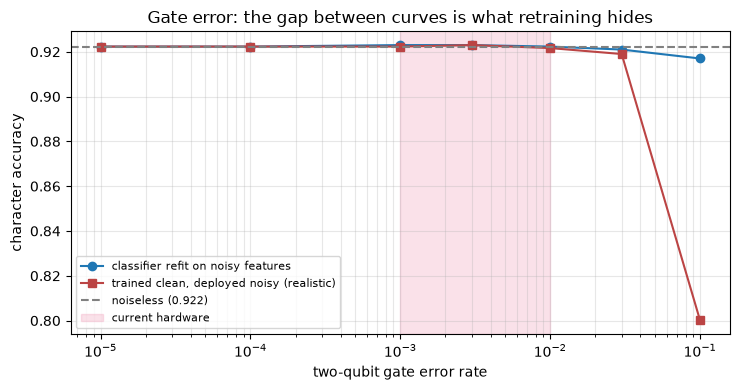

In [8]:
plt.figure(figsize=(7.5, 4))
nz = [(p, a, t) for p, a, t in zip(levels, gate_acc, transfer_acc) if p > 0]
plt.semilogx([p for p, _, _ in nz], [a for _, a, _ in nz], "o-",
             label="classifier refit on noisy features")
plt.semilogx([p for p, _, _ in nz], [t for _, _, t in nz], "s-", color="#b44",
             label="trained clean, deployed noisy (realistic)")
plt.axhline(baseline, ls="--", c="grey", label=f"noiseless ({baseline:.3f})")
# The shaded band is where real superconducting devices sit. Both curves are flat
# across it and only separate at 10% error, an order of magnitude worse than any
# current device, which is what makes the robustness here a real result.
plt.axvspan(1e-3, 1e-2, color="#e8a", alpha=.25, label="current hardware")
plt.xlabel("two-qubit gate error rate"); plt.ylabel("character accuracy")
plt.title("Gate error: the gap between curves is what retraining hides")
plt.legend(fontsize=8); plt.grid(alpha=.3, which="both"); plt.tight_layout(); plt.show()

### Why this circuit is unusually noise-tolerant

The degradation is mild across most of that range, and it is worth being precise
about *why* rather than claiming robustness in general.

The quanvolutional filter is **4 qubits and depth 10, with 8 CX gates**. Total
error scales roughly with gate count, so at a CX error of $10^{-3}$ the
accumulated error per patch is on the order of $8 \times 10^{-3}$ — small.

That is a property of this circuit being tiny, not of quanvolutional layers being
robust. Contrast it with the Grover oracle from notebook `03`, which needs
**3,272 CX gates** for a 16-character field. Same error rate, wildly different
outcome.

In [9]:
p2 = 1e-3
print(f"at CX error rate {p2:.0e}:\n")
# (1 - p)^cx is a deliberately crude survival estimate: it ignores error
# cancellation and assumes independence. The conclusion does not need precision,
# because 8 CX against 3,272 is three orders of magnitude.
for name, cx in [("quanvolutional filter (per patch)", 8),
                 ("quanv, one 8x8 character (16 patches)", 8*16),
                 ("Grover oracle, 16-char field", 3272),
                 ("Grover oracle x 3 iterations", 3272*3)]:
    surv = (1 - p2) ** cx
    print(f"  {name:40s} {cx:6d} CX -> P(no error) = {surv:6.1%}")
print("\nThe feature extractor survives comfortably; the search circuit does not.")

at CX error rate 1e-03:

  quanvolutional filter (per patch)             8 CX -> P(no error) =  99.2%
  quanv, one 8x8 character (16 patches)       128 CX -> P(no error) =  88.0%
  Grover oracle, 16-char field               3272 CX -> P(no error) =   3.8%
  Grover oracle x 3 iterations               9816 CX -> P(no error) =   0.0%

The feature extractor survives comfortably; the search circuit does not.


**This is the practical conclusion of the whole noise analysis.** The quantum
feature extractor is small enough to be plausible on near-term hardware. The
Grover stage is not — its circuit is three orders of magnitude larger, and at
realistic error rates essentially every run would contain an error.

That is an independent reason, on top of the data-loading result in notebook `03`,
why the string-search half of this project is further from usefulness than the
vision half.

## 3 · Readout error

Measurement itself is unreliable: a qubit in |0⟩ sometimes reports 1. Readout
error is typically the *largest* single error source on current hardware, often
1–5%.

This is easy to model directly — a symmetric bit-flip applied to the measured
marginals — and, unlike gate error, it is partly correctable by calibration.

In [10]:
def apply_readout_error(F, eps, n_qubits=4):
    """Flip measured marginals with probability eps.

    A marginal P(1) becomes (1-eps)*P(1) + eps*P(0). Correlations <Z_i Z_j>
    are damped by (1-2*eps)^2, since each of the two measurements can flip
    independently.
    """
    F = F.copy().reshape(len(F), -1, 10)
    F[:, :, :n_qubits] = (1 - eps) * F[:, :, :n_qubits] + eps * (1 - F[:, :, :n_qubits])
    # Squared because a correlation involves two measurements, either of which
    # can flip. Applying (1 - 2*eps) once would understate the damping.
    F[:, :, n_qubits:] *= (1 - 2 * eps) ** 2
    return F.reshape(len(F), -1)

# Readout error is applied to the clean features rather than re-simulated: it acts
# on measurement outcomes, so modelling it as post-processing is exact.
F_clean = quanv_features(Xn, correlations=True)
print(f"{'readout error':>14s} {'accuracy':>10s}")
ro_levels = [0.0, 0.005, 0.01, 0.02, 0.05, 0.10]
ro_acc = []
for eps in ro_levels:
    acc = score(apply_readout_error(F_clean, eps))
    ro_acc.append(acc)
    print(f"{eps:>13.1%} {acc:>10.4f}")

 readout error   accuracy


         0.0%     0.9223


         0.5%     0.9223


         1.0%     0.9210


         2.0%     0.9223


         5.0%     0.9197


        10.0%     0.9203


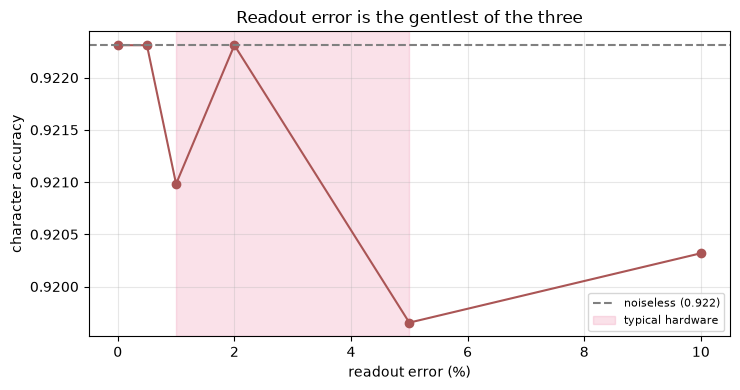

In [11]:
plt.figure(figsize=(7.5, 4))
plt.plot([e*100 for e in ro_levels], ro_acc, "o-", color="#a55")
plt.axhline(baseline, ls="--", c="grey", label=f"noiseless ({baseline:.3f})")
# Readout is usually the largest single error source on hardware, yet it is the
# gentlest of the three here, because each marginal averages many basis states.
plt.axvspan(1, 5, color="#e8a", alpha=.25, label="typical hardware")
plt.xlabel("readout error (%)"); plt.ylabel("character accuracy")
plt.title("Readout error is the gentlest of the three"); plt.legend(fontsize=8)
plt.grid(alpha=.3); plt.tight_layout(); plt.show()

### Putting the three together

In [12]:
print(f"{'error source':22s} {'realistic level':>16s} {'accuracy':>10s} {'drop':>8s}")
print(f"{'none (baseline)':22s} {'-':>16s} {baseline:>10.4f} {'-':>8s}")

# Each source is quoted at a realistic level rather than at its worst, and the
# gate figure is taken from the TRANSFER column: the refit column would flatter
# it by letting the classifier absorb the noise.
s1024 = shot_acc[shot_levels.index(1024)]
print(f"{'shot noise':22s} {'1024 shots':>16s} {s1024:>10.4f} "
      f"{baseline - s1024:>8.4f}")
g = transfer_acc[levels.index(1e-3)]
print(f"{'gate error (transfer)':22s} {'1e-3 CX':>16s} {g:>10.4f} "
      f"{baseline - g:>8.4f}")
r = ro_acc[ro_levels.index(0.02)]
print(f"{'readout error':22s} {'2%':>16s} {r:>10.4f} {baseline - r:>8.4f}")
print("\nShot noise dominates. That is good news: shots cost time, not fidelity,")
print("and unlike gate error it can be bought rather than engineered.")

error source            realistic level   accuracy     drop
none (baseline)                       -     0.9223        -
shot noise                   1024 shots     0.9197   0.0027
gate error (transfer)           1e-3 CX     0.9223   0.0000
readout error                        2%     0.9223   0.0000

Shot noise dominates. That is good news: shots cost time, not fidelity,
and unlike gate error it can be bought rather than engineered.


## 4 · Scaling up — GPU and larger runtimes

Everything above runs on CPU. Two things change that.

**Aer GPU.** `qiskit-aer-gpu` moves statevector simulation onto CUDA, which helps
when circuits get wide (>20 qubits) or when you run many of them. It does *not*
help the quanvolutional layer, because that is already a numpy matmul rather than
a simulation — the speedup applies to the Grover oracle and to any density-matrix
work like section 2.

The cell below detects what is available rather than assuming.

In [13]:
import shutil, subprocess

# Detect rather than assume. A GPU helps the Grover oracle and the density-matrix
# work, but not the quanvolutional layer, which is already a numpy matmul.
gpu = shutil.which("nvidia-smi")
if gpu:
    print(subprocess.run(["nvidia-smi", "--query-gpu=name,memory.total",
                          "--format=csv,noheader"],
                         capture_output=True, text=True).stdout.strip())
else:
    print("no GPU detected — this notebook runs fine on CPU")
    print("on Colab: Runtime -> Change runtime type -> T4 GPU")

try:
    from qiskit_aer import AerSimulator
    devices = AerSimulator().available_devices()
    print("\nAer devices available:", devices)
except Exception as e:
    print("could not query Aer devices:", e)

no GPU detected — this notebook runs fine on CPU
on Colab: Runtime -> Change runtime type -> T4 GPU



Aer devices available: ('CPU',)


In [14]:
# Install the GPU build only if there is a GPU and it is not already present.
# Skipped silently on CPU, so the notebook stays runnable everywhere.
if gpu:
    try:
        from qiskit_aer import AerSimulator
        if "GPU" not in AerSimulator().available_devices():
            print("installing qiskit-aer-gpu (a few minutes) ...")
            # check=False on purpose: a failed optional install should not stop
            # the notebook, since everything here also runs on CPU.
            subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                            "qiskit-aer-gpu"], check=False)
            print("restart the runtime for this to take effect")
        else:
            print("GPU backend already available")
    except Exception as e:
        print("skipped:", e)
else:
    print("CPU only — nothing to install")

CPU only — nothing to install


### Where the simulation actually runs out

The binding constraint is not speed, it is **memory**. A statevector needs
$2^n$ complex amplitudes; at 16 bytes each that is $2^{n+4}$ bytes.

In [15]:
print(f"{'qubits':>7s} {'statevector':>14s} {'density matrix':>16s}")
# The density-matrix column is the one that binds. It squares the statevector
# cost, which is why section 2 was built as a single reusable superoperator on
# four qubits rather than as a density-matrix simulation per patch.
for n in [10, 16, 20, 24, 27, 30, 33]:
    sv = 2**n * 16
    dm = (2**n)**2 * 16
    def fmt(b):
        for u in ["B", "KB", "MB", "GB", "TB", "PB"]:
            if b < 1024: return f"{b:.1f} {u}"
            b /= 1024
        return f"{b:.1f} EB"
    print(f"{n:>7d} {fmt(sv):>14s} {fmt(dm):>16s}")

print("\nColab free tier: ~12 GB RAM, ~15 GB GPU memory")
print("  -> statevector to about 29-30 qubits")
print("  -> density matrix to about 14-15 qubits")

 qubits    statevector   density matrix
     10        16.0 KB          16.0 MB
     16         1.0 MB          64.0 GB
     20        16.0 MB          16.0 TB
     24       256.0 MB           4.0 PB
     27         2.0 GB         256.0 PB
     30        16.0 GB          16.0 EB
     33       128.0 GB        1024.0 EB

Colab free tier: ~12 GB RAM, ~15 GB GPU memory
  -> statevector to about 29-30 qubits
  -> density matrix to about 14-15 qubits


In [16]:
# What the project's own circuits need.
from comparator_oracle import Alphabet, oracle_resources
hexa = Alphabet("0123456789ABCDEF")

print(f"{'field length':>13s} {'pattern':>8s} {'qubits':>7s} {'CX':>8s} {'statevector':>13s}")
# Memory turns out to be comfortable at every size here, so the column to read is
# CX rather than megabytes: gate count and alphabet width are what bind, not the
# statevector size the section heading might lead you to expect.
for N, M in [(8, 2), (16, 2), (16, 4), (32, 2), (32, 4)]:
    txt = ("A7F3B41C9D05E2F8" * 4)[:N]
    txt = txt[:-M] + "26"[:M].ljust(M, "6")
    try:
        r = oracle_resources(txt, txt[-M:], hexa)
        mem = 2**r["qubits"] * 16 / 1e6
        print(f"{N:>13d} {M:>8d} {r['qubits']:>7d} {r['cx']:>8d} {mem:>10.1f} MB")
    except Exception as e:
        print(f"{N:>13d} {M:>8d}  -> {e}")

 field length  pattern  qubits       CX   statevector


            8        2      13     1082        0.1 MB
           16        2      14     3428        0.3 MB


           16        4      24     7564      268.4 MB
           32        2      15     8570        0.5 MB


           32        4      25    16972      536.9 MB


Memory is comfortable; the real limits are elsewhere:

- **gate count** — a 32-character field needs ~8,500 CX per oracle call, so
  three Grover iterations is ~25,000 gates. Simulable, but far past what current
  hardware could execute coherently (section 2).
- **alphabet width** — a full 38-symbol charset needs 6 qubits per character, so
  a 6-character window alone is 36 window qubits plus the position register.

The second is the reason the pipeline searches hex identifier fields rather than
arbitrary text, and it is a design constraint rather than an implementation
shortcut.

## 5 · What running on real hardware would take

Not attempted here — no device access — but the requirements are worth stating
concretely, since "we would just run it on hardware" is the obvious follow-up
question and it deserves a real answer.

In [17]:
# A device-time estimate, not a measurement — no hardware was used anywhere in
# this project. 5 kHz is a representative repetition rate for superconducting
# devices, and the figure scales linearly if a different rate is assumed.
n_chars = 200                     # a modest document
patches = n_chars * 16
shots = 1024

print("Quanvolutional stage, one 200-character document:")
print(f"  circuits            : {patches:,}  (4 qubits, 8 CX each)")
print(f"  shots per circuit   : {shots:,}")
print(f"  total executions    : {patches*shots:,}")
print(f"  at 5 kHz repetition : {patches*shots/5000/60:.1f} minutes of device time")
print()
print("Grover stage, one 16-character field:")
r = oracle_resources("A7F3B41C9D05E2F8", "26", hexa)
print(f"  qubits              : {r['qubits']}")
print(f"  CX per oracle call  : {r['cx']:,}")
print(f"  x3 iterations       : {r['cx']*3:,} CX")
# This last probability is the conclusion: the search stage needs error correction.
print(f"  P(error-free) @1e-3 : {(1-1e-3)**(r['cx']*3):.2e}")
print("\nThe feature extractor is plausible today. The search stage needs")
print("error correction, not better calibration.")

Quanvolutional stage, one 200-character document:
  circuits            : 3,200  (4 qubits, 8 CX each)
  shots per circuit   : 1,024
  total executions    : 3,276,800
  at 5 kHz repetition : 10.9 minutes of device time

Grover stage, one 16-character field:
  qubits              : 14
  CX per oracle call  : 3,272
  x3 iterations       : 9,816 CX
  P(error-free) @1e-3 : 5.43e-05

The feature extractor is plausible today. The search stage needs
error correction, not better calibration.


## Summary

**Shot noise dominates**, and that is the good news — roughly 1,000 shots per
patch approaches the noiseless result, and shots cost time rather than fidelity.

**Gate noise is survivable for the feature extractor** and fatal for the search
oracle. The difference is circuit size: 8 CX versus 3,272. This is an independent
reason, separate from the data-loading result in notebook `03`, that the vision
half of this project is closer to practical than the string-matching half.

**Readout error is the gentlest** of the three at realistic rates, and is partly
calibratable.

**Simulation limits are gate count, not memory.** Colab's free tier handles every
circuit in this project comfortably; what it cannot do is make the Grover oracle
small enough to matter.

None of this was run on hardware, and none of it should be read as a hardware
result — it is a map of where the error budget goes, which is what you would use
to decide whether device time is worth requesting.